In [26]:

import pandas as pd 


import matplotlib.pyplot as plt 

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.compose import ColumnTransformer


from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
crop_df = pd.read_csv('Crop_recommendationV2.csv')
crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [7]:
crop_df.shape

(2200, 23)

In [8]:
crop_df.isnull().sum()

N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
label                     0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
dtype: int64

In [9]:
crop_df['no_label'] = pd.Categorical(crop_df.label).codes

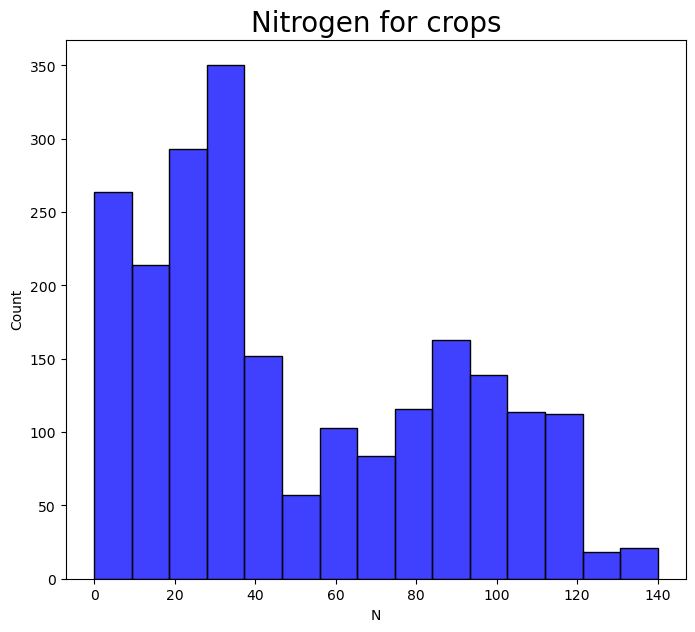

In [10]:
plt.figure(figsize=(8,7))
sns.histplot(x='N',data=crop_df,color='b');
plt.title("Nitrogen for crops",{'fontsize':20});

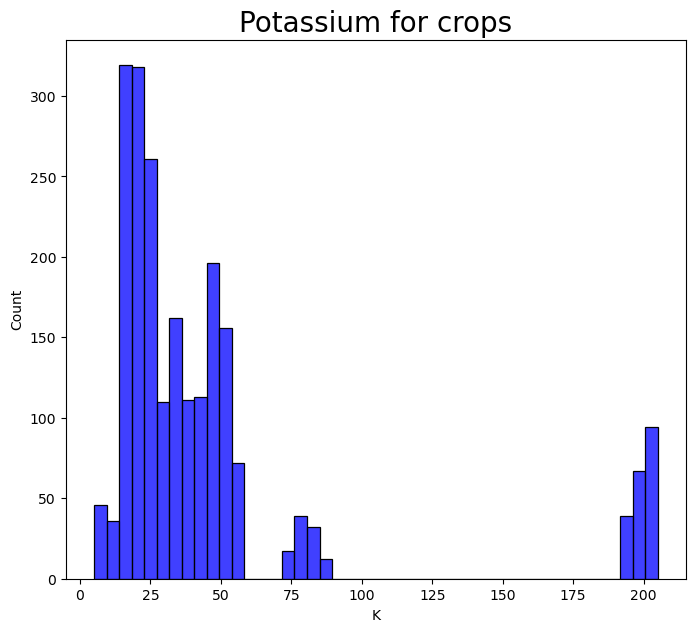

In [11]:
plt.figure(figsize=(8,7))
sns.histplot(x='K',data=crop_df,color='b');
plt.title("Potassium for crops",{'fontsize':20});

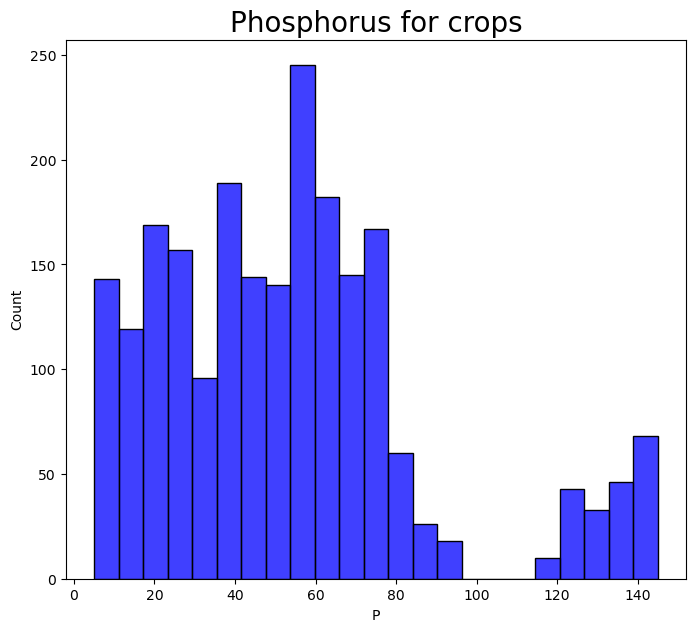

In [12]:
plt.figure(figsize=(8,7))
sns.histplot(x='P',data=crop_df,color='b');
plt.title("Phosphorus for crops",{'fontsize':20});

In [13]:
crop_df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency', 'no_label'],
      dtype='object')

# Exploratory Data Analysis (EDA)

Goal: understand feature distributions, target balance, correlations, and feature-label relationships to inform a model predicting `label` (crop type).

Focus:
- Target balance: are crop classes balanced?
- Numeric distributions: ranges/outliers for agronomic features.
- Correlations: multicollinearity among inputs.
- Feature-label relationships: which features separate classes.


Class counts (top 10):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
Name: count, dtype: int64

Number of classes: 22


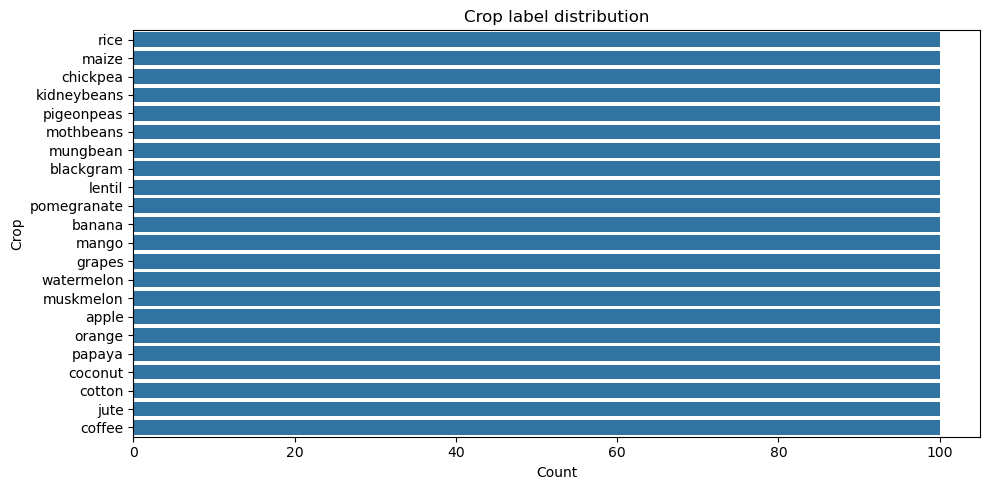

In [14]:
# Target balance (label counts)
plt.figure(figsize=(10,5))
sns.countplot(y='label', data=crop_df, order=crop_df['label'].value_counts().index)
plt.title('Crop label distribution');
plt.xlabel('Count'); plt.ylabel('Crop');
plt.tight_layout()

# Print numeric counts
label_counts = crop_df['label'].value_counts()
print('Class counts (top 10):')
print(label_counts.head(10))
print('\nNumber of classes:', label_counts.shape[0])


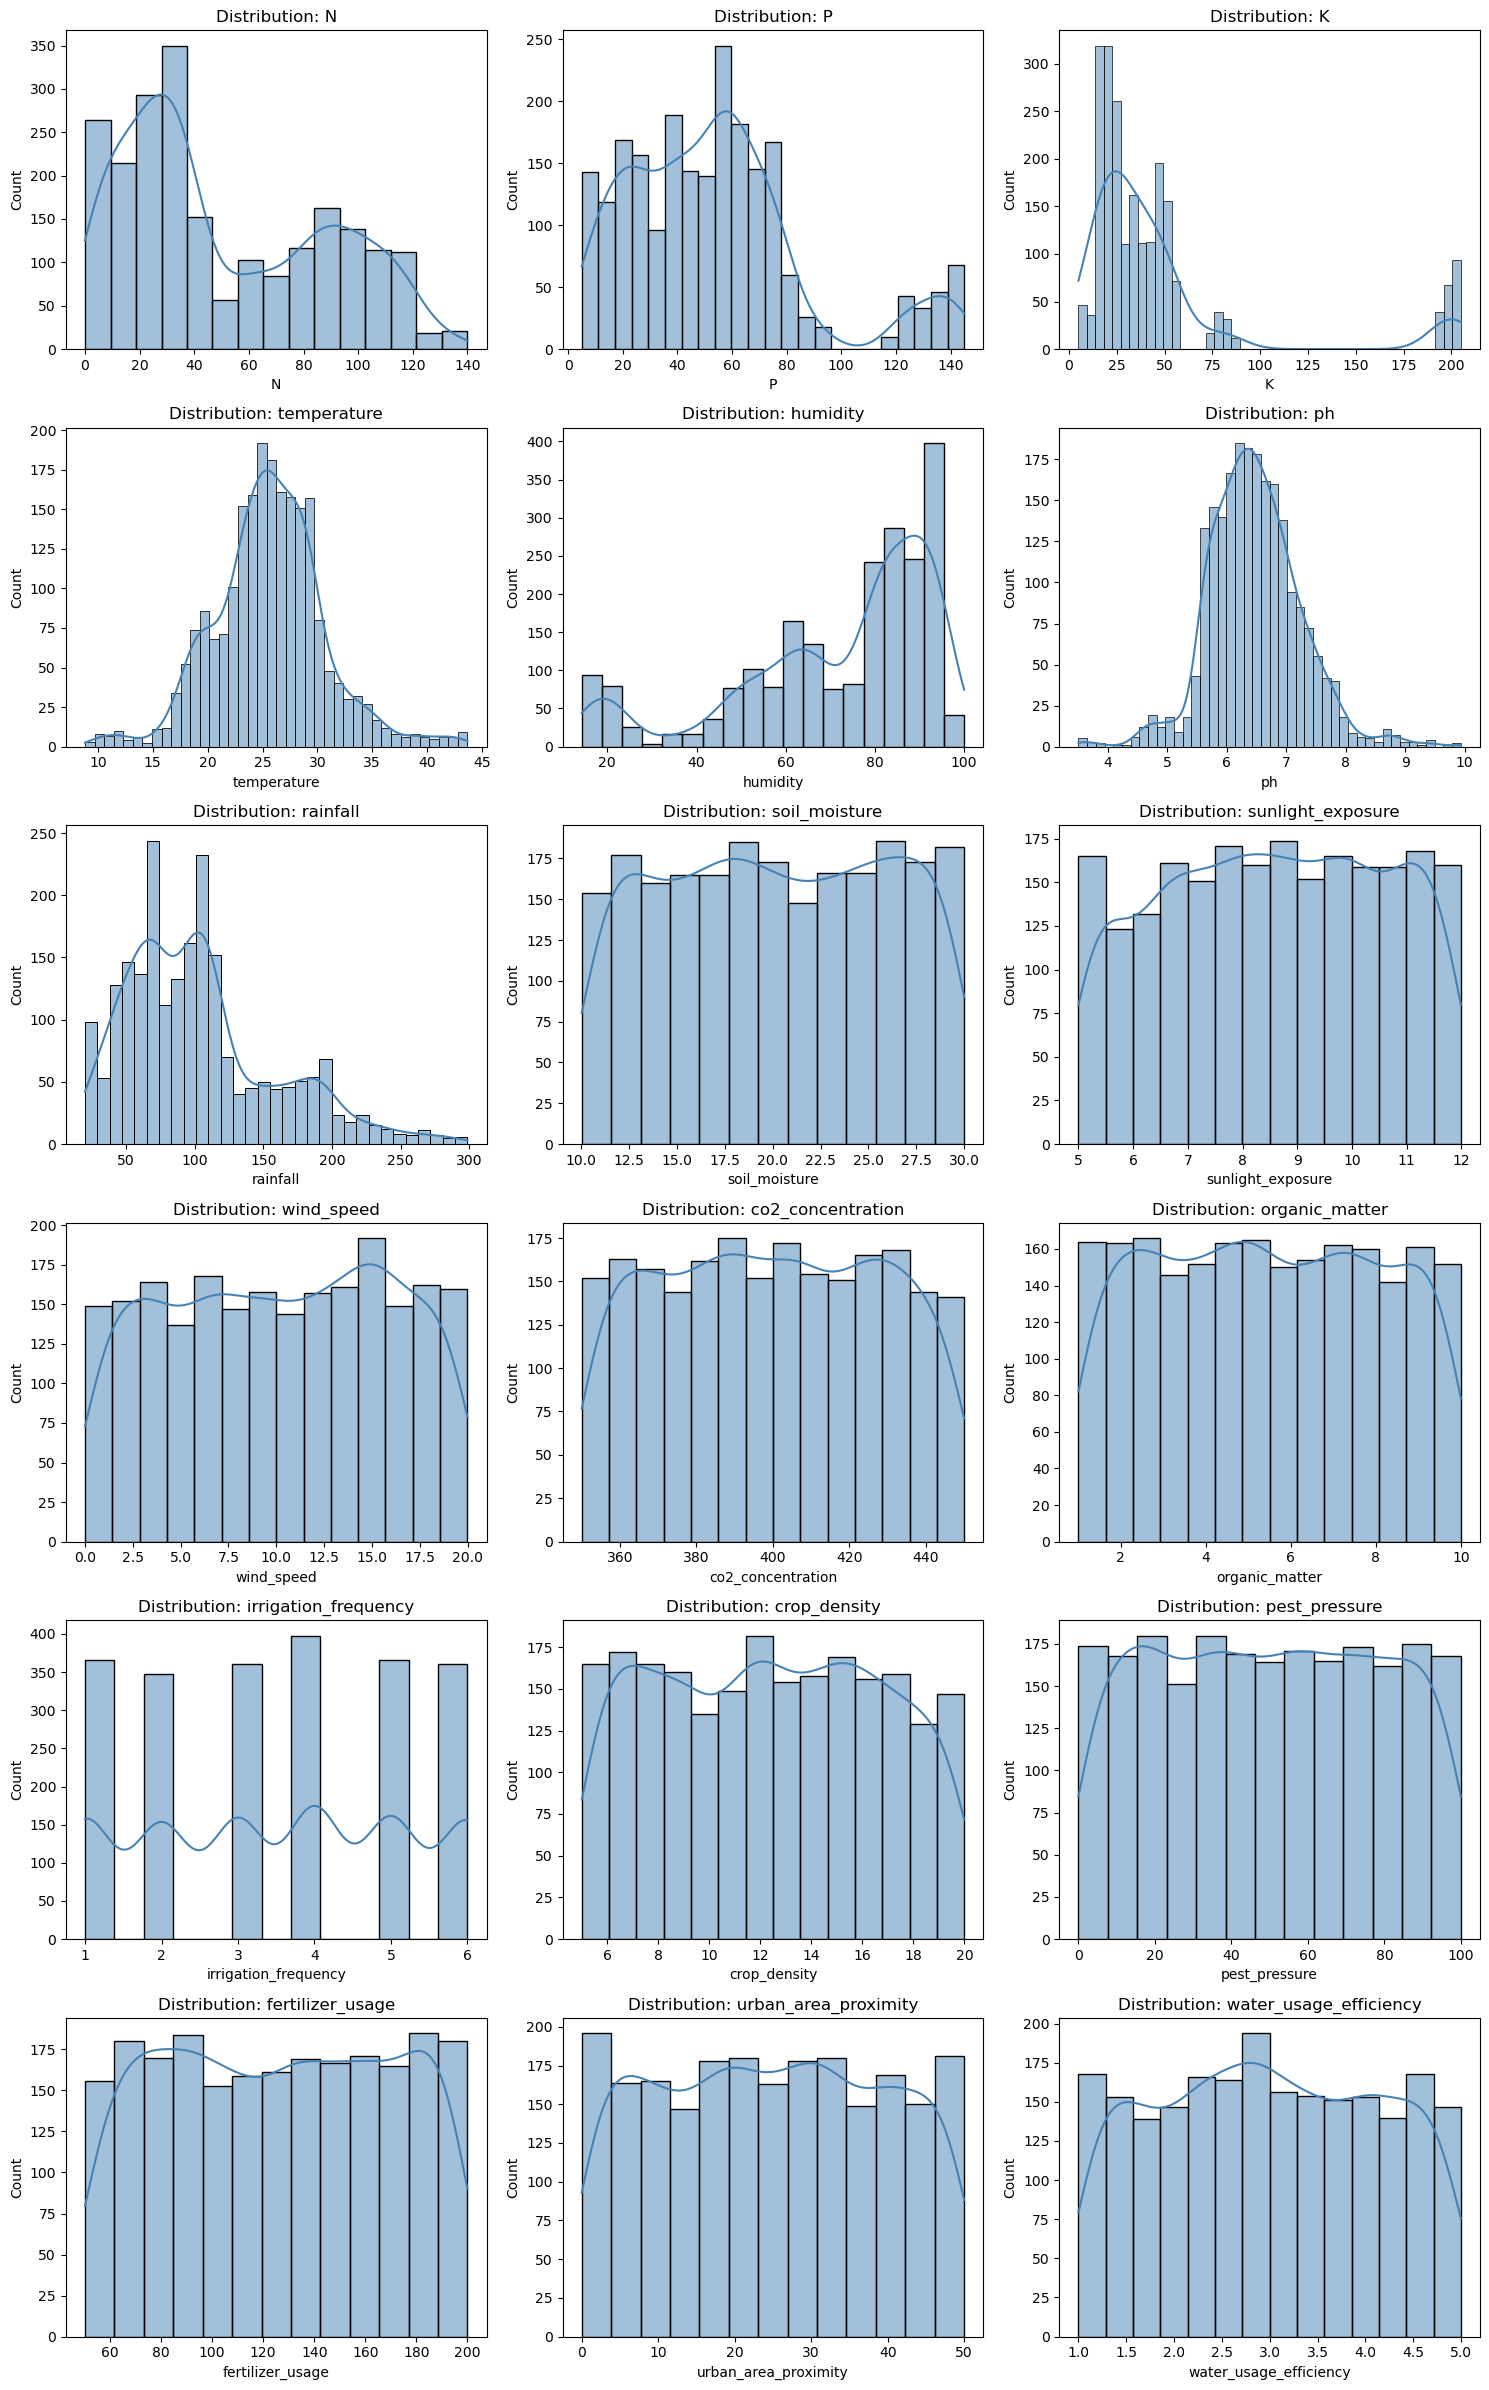

In [15]:
# Numeric feature distributions
num_cols = ['N','P','K','temperature','humidity','ph','rainfall',
            'soil_moisture','sunlight_exposure','wind_speed','co2_concentration',
            'organic_matter','irrigation_frequency','crop_density','pest_pressure',
            'fertilizer_usage','urban_area_proximity','water_usage_efficiency']

# Filter for columns that exist
num_cols = [c for c in num_cols if c in crop_df.columns]

fig, axes = plt.subplots(nrows=int(np.ceil(len(num_cols)/3)), ncols=3, figsize=(15, 4*int(np.ceil(len(num_cols)/3))))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(crop_df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution: {col}')

# Hide unused axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()


Top correlations:
        level_0               level_1         0
17            P                     K  0.736232
48  temperature              humidity  0.205320
34            K              humidity  0.190859
3             N              humidity  0.190688
4             N                    ph  0.096683
63     humidity              rainfall  0.094423
8             N            wind_speed  0.068319
5             N              rainfall  0.059020
31            P  urban_area_proximity  0.044838
85           ph  urban_area_proximity  0.043606


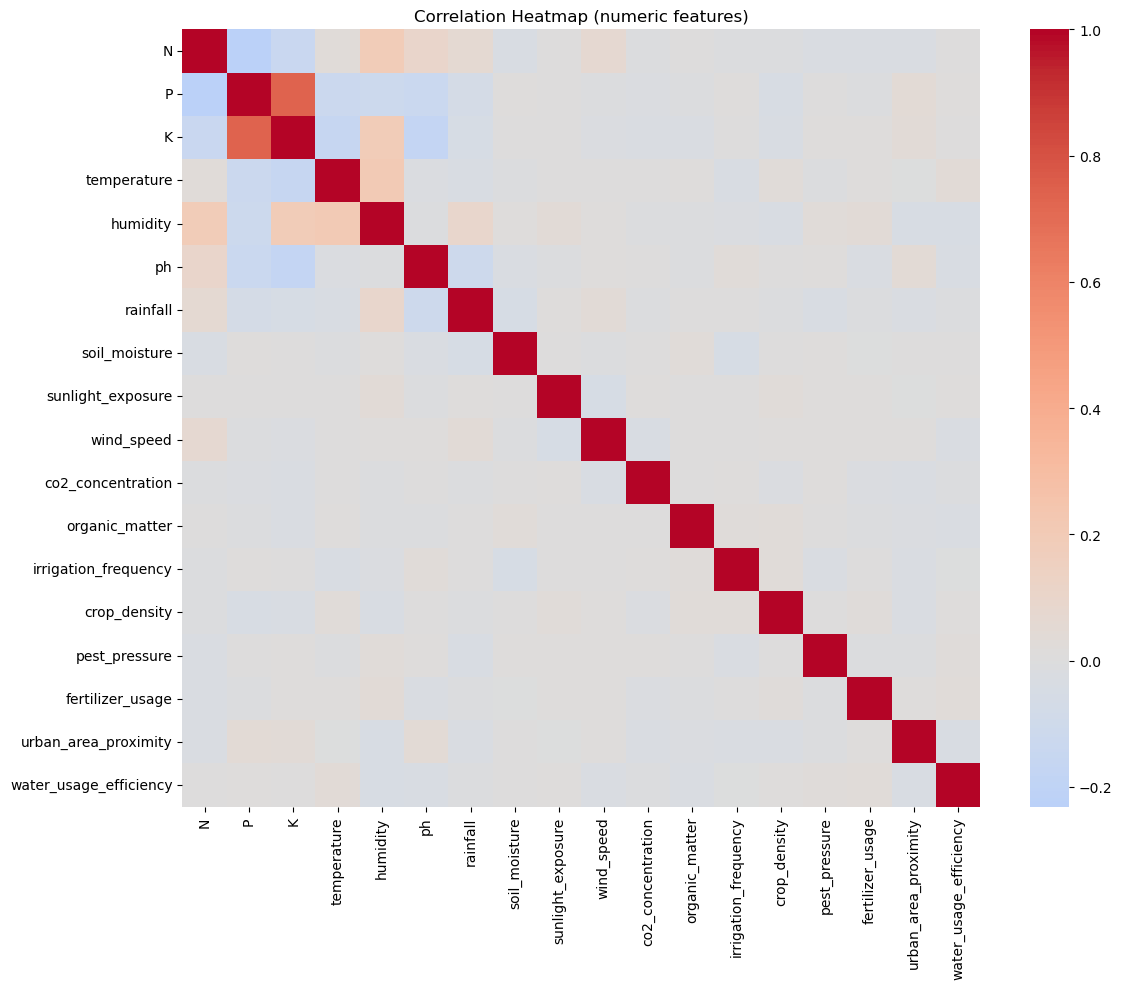

In [16]:
# Correlation heatmap among numeric features
corr_cols = [c for c in num_cols if crop_df[c].dtype != 'object']
corr = crop_df[corr_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric features)');
plt.tight_layout()

# Show top correlated pairs
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .sort_values(0, ascending=False)
)
print('Top correlations:')
print(corr_pairs.head(10))


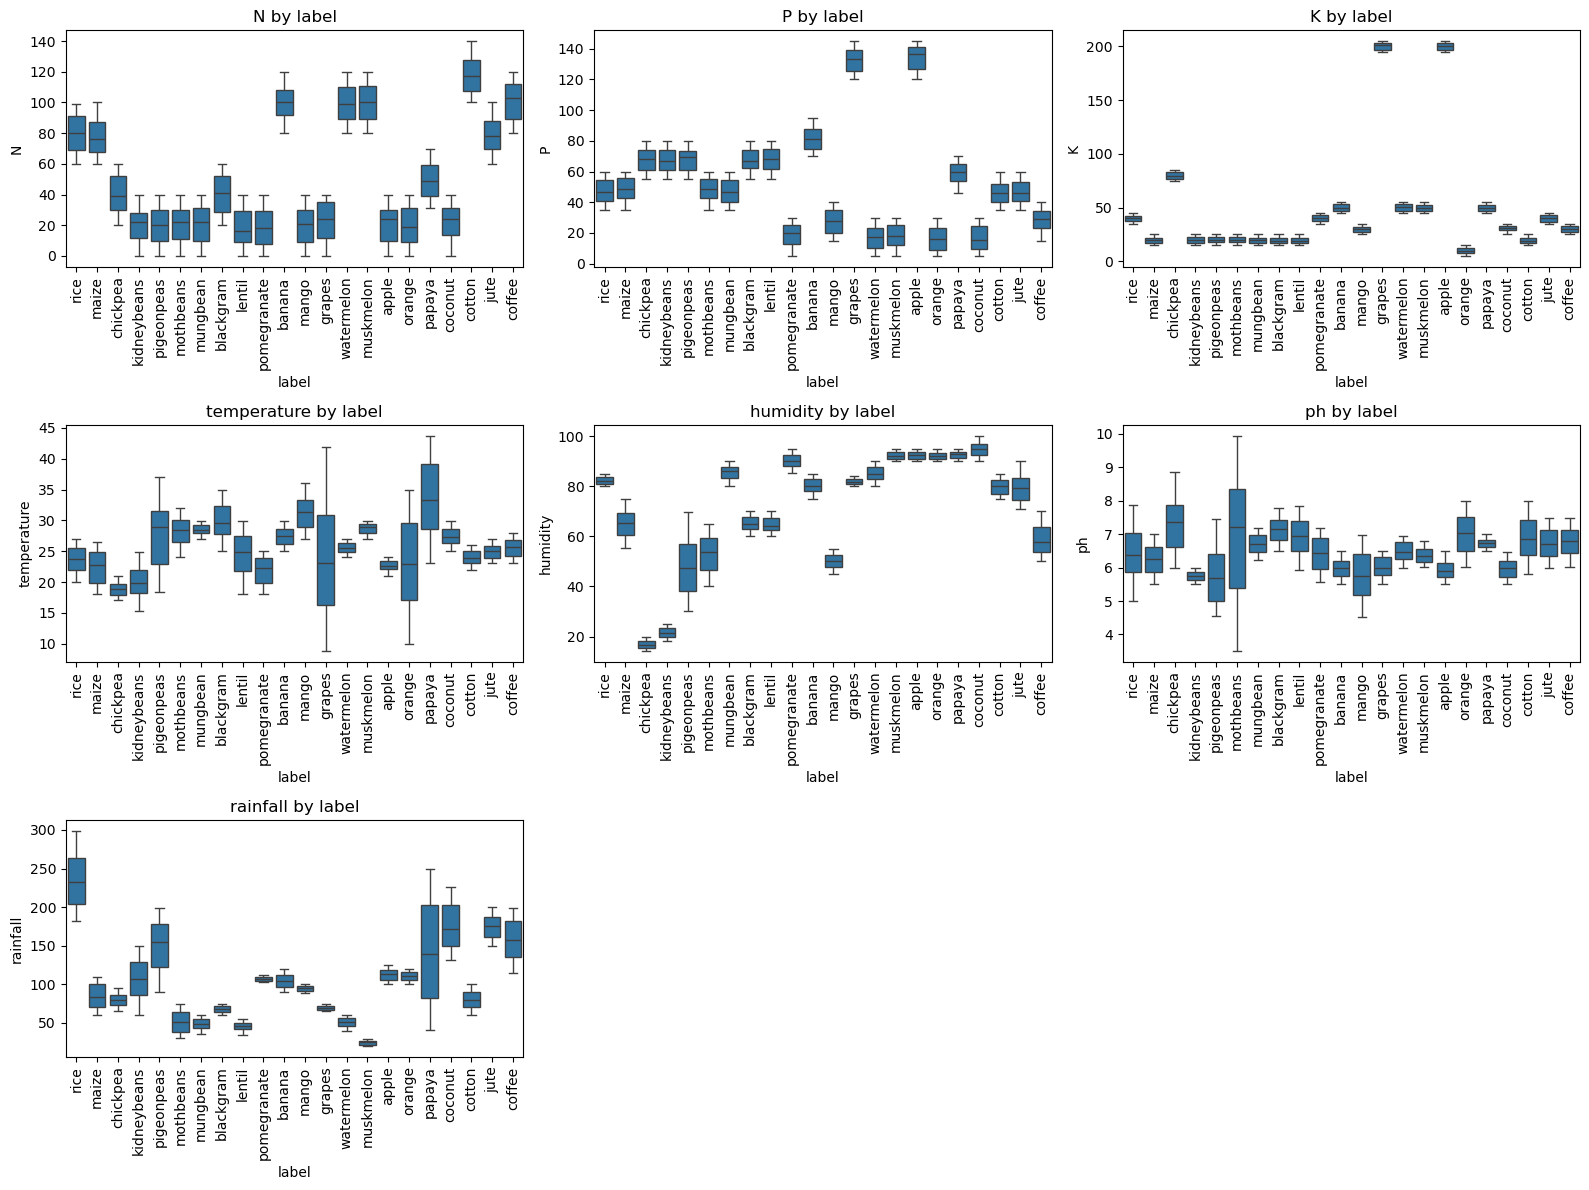

In [17]:
# Feature vs label: boxplots for selected features
sel_cols = ['N','P','K','temperature','humidity','ph','rainfall']
sel_cols = [c for c in sel_cols if c in crop_df.columns]

fig, axes = plt.subplots(nrows=int(np.ceil(len(sel_cols)/3)), ncols=3, figsize=(16, 4*int(np.ceil(len(sel_cols)/3))))
axes = axes.flatten()
for i, col in enumerate(sel_cols):
    sns.boxplot(x='label', y=col, data=crop_df, ax=axes[i])
    axes[i].set_title(f'{col} by label')
    axes[i].tick_params(axis='x', rotation=90)
for j in range(len(sel_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()


## Split


In [18]:
X = crop_df.drop(columns=['label','no_label']).copy()
y = crop_df['no_label'].copy()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
X_train.head()

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
1607,0,18,14,29.771494,92.007200,7.207991,114.416179,20.888830,1,6.468971,...,1.140748,5,7.012204,38.266353,150.292430,1,15.335108,2,87.392565,4.738505
1212,9,122,201,29.587484,80.919344,5.570291,68.064173,15.125944,2,11.680435,...,3.248109,1,19.521609,30.790300,53.286861,3,28.286155,3,91.294786,4.524708
362,11,71,24,21.140114,22.718235,5.606620,141.605672,11.895561,1,10.697693,...,5.167022,1,8.611567,92.298964,75.310097,3,10.020322,1,59.799905,3.581771
566,38,38,18,26.310518,61.187491,6.294130,35.734038,23.306986,2,11.190040,...,5.300931,3,17.211387,24.382088,167.580196,3,2.829255,1,49.525093,4.894156
1671,18,12,8,12.590940,91.816688,6.206053,119.391672,27.154032,1,6.762180,...,1.050747,6,7.427602,72.923052,55.320303,1,21.011290,2,83.108779,4.005910


In [21]:
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [24]:
categorical_cols = X_train.select_dtypes(include=['object','category']).columns
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

from sklearn.linear_model import LogisticRegression
clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])
clf.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train[numeric_cols])
X_test_scaled = scalar.transform(X_test[numeric_cols])

In [ ]:
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object','category']).columns

In [27]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', class_weight='balanced')
}

In [30]:
results = []
for name, est in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('model', est)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    results.append((name, acc, f1m))
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1m:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9591 | Macro F1: 0.9585
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       0.91      1.00      0.95        20
           7       1.00      1.00      1.00        20
           8       0.79      0.95      0.86        20
           9       1.00      1.00      1.00        20
          10       0.95      0.90      0.92        20
          11       1.00      0.90      0.95        20
          12       0.95      1.00      0.98        20
          13       0.90      0.90      0.90        20
          14       0.95      1.00      0.98        20
          15       0.91      1.00      0.95        20
          16       1.00 

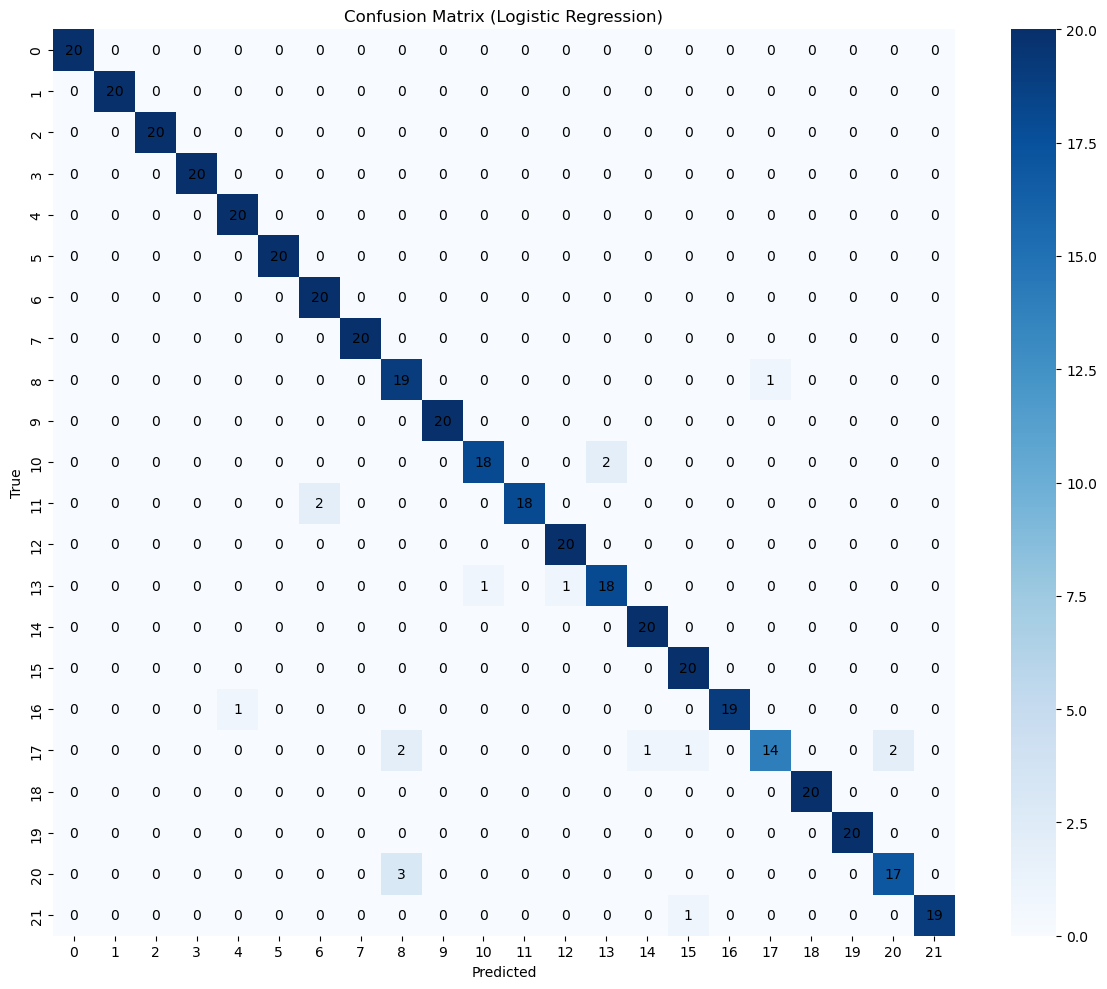

In [31]:
# Confusion matrix for best model (Logistic Regression pipeline)
from sklearn.metrics import confusion_matrix
import itertools

best_pipe = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels_sorted = np.sort(y_train.unique())
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted'); plt.ylabel('True');
plt.tight_layout()

# Optional: show numeric values over cells
for (i, j), v in np.ndenumerate(cm):
    plt.text(j+0.5, i+0.5, str(v), ha='center', va='center', color='black')
plt.show()


In [32]:
# Stratified 5-fold CV for stability (macro F1)
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_lr = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

cv_scores = cross_val_score(pipe_lr, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print('Stratified 5-fold Macro F1:', np.round(cv_scores, 4))
print('Mean:', cv_scores.mean().round(4), 'Std:', cv_scores.std().round(4))


Stratified 5-fold Macro F1: [0.9604 0.9433 0.956  0.9635 0.9613]
Mean: 0.9569 Std: 0.0072


In [33]:
# Save the trained Logistic Regression pipeline for inference
import joblib

final_pipe = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
final_pipe.fit(X_train, y_train)

model_path = 'crop_label_pipeline.joblib'
joblib.dump(final_pipe, model_path)
print(f'Saved pipeline to {model_path}')


Saved pipeline to crop_label_pipeline.joblib


In [34]:
# Load pipeline and run a simple inference on one sample
import joblib
loaded_pipe = joblib.load('crop_label_pipeline.joblib')

# Use one row from X_test
sample = X_test.iloc[[0]].copy()
pred_code = loaded_pipe.predict(sample)[0]

# Map numeric code back to original label
code_to_label = dict(zip(crop_df['no_label'], crop_df['label']))
pred_label = code_to_label.get(pred_code, pred_code)

print('Predicted class code:', pred_code)
print('Predicted crop label:', pred_label)


Predicted class code: 16
Predicted crop label: orange


In [41]:
# Interactive Model Testing - Enter your own inputs and see predictions
import joblib
import pandas as pd
import json

# Load the trained model and label map
loaded_pipe = joblib.load('crop_label_pipeline.joblib')

# Load label mapping
with open('label_map.json', 'r') as f:
    label_map = json.load(f)

# Reverse the mapping (code -> label)
code_to_label = {str(v): k for k, v in label_map.items()}

# Get the feature names from the original data
original_features = crop_df.drop(columns=['label', 'no_label']).columns.tolist()

print("=" * 80)
print("🌾 INTERACTIVE CROP PREDICTION MODEL TEST")
print("=" * 80)
print("\nEnter values for each feature to get a crop prediction!")
print("\nFeatures to enter:")
print("  Numeric: N, P, K, temperature, humidity, ph, rainfall, soil_moisture,")
print("           wind_speed, co2_concentration, organic_matter, irrigation_frequency,")
print("           crop_density, pest_pressure, fertilizer_usage, urban_area_proximity,")
print("           frost_risk, water_usage_efficiency")
print("\n  Categorical: soil_type, sunlight_exposure, growth_stage, water_source_type")
print("-" * 80)

# Sample inputs for easy testing
test_cases = [
    {
        "name": "Rice Growing (High Rainfall)",
        "N": 90, "P": 42, "K": 43, "temperature": 20.88, "humidity": 82,
        "ph": 6.5, "rainfall": 202.94, "soil_moisture": 29.45, "soil_type": "Loamy",
        "sunlight_exposure": "High", "wind_speed": 10.11, "co2_concentration": 435.61,
        "organic_matter": 3.12, "irrigation_frequency": 4, "crop_density": 11.74,
        "pest_pressure": 57.61, "fertilizer_usage": 188.19, "growth_stage": "Vegetative",
        "urban_area_proximity": 2.72, "water_source_type": "Rainwater",
        "frost_risk": "Low", "water_usage_efficiency": 1.19
    },
    {
        "name": "Corn Growing (Dry Climate)",
        "N": 120, "P": 80, "K": 60, "temperature": 25.5, "humidity": 70,
        "ph": 7.0, "rainfall": 150, "soil_moisture": 35, "soil_type": "Sandy",
        "sunlight_exposure": "High", "wind_speed": 8, "co2_concentration": 420,
        "organic_matter": 4, "irrigation_frequency": 3, "crop_density": 50,
        "pest_pressure": 20, "fertilizer_usage": 250, "growth_stage": "Flowering",
        "urban_area_proximity": 5, "water_source_type": "Irrigation",
        "frost_risk": "Low", "water_usage_efficiency": 0.9
    },
    {
        "name": "Wheat Growing (Moderate Climate)",
        "N": 100, "P": 50, "K": 50, "temperature": 18, "humidity": 75,
        "ph": 6.8, "rainfall": 180, "soil_moisture": 40, "soil_type": "Loamy",
        "sunlight_exposure": "Medium", "wind_speed": 6, "co2_concentration": 410,
        "organic_matter": 5, "irrigation_frequency": 2, "crop_density": 30,
        "pest_pressure": 10, "fertilizer_usage": 200, "growth_stage": "Vegetative",
        "urban_area_proximity": 3, "water_source_type": "Rainwater",
        "frost_risk": "Medium", "water_usage_efficiency": 0.85
    },
    {
        "name": "Tomato Growing (High Soil Quality)",
        "N": 60, "P": 70, "K": 80, "temperature": 22, "humidity": 80,
        "ph": 6.5, "rainfall": 120, "soil_moisture": 50, "soil_type": "Loamy",
        "sunlight_exposure": "High", "wind_speed": 3, "co2_concentration": 450,
        "organic_matter": 8, "irrigation_frequency": 5, "crop_density": 200,
        "pest_pressure": 30, "fertilizer_usage": 150, "growth_stage": "Flowering",
        "urban_area_proximity": 1, "water_source_type": "Irrigation",
        "frost_risk": "Low", "water_usage_efficiency": 1.2
    }
]

print(f"\n📋 RUNNING {len(test_cases)} PRE-DEFINED TEST CASES\n")

results = []
for i, test_case in enumerate(test_cases, 1):
    test_name = test_case.pop("name")
    
    # Create DataFrame with the test inputs
    test_df = pd.DataFrame([test_case])
    
    # Make prediction
    pred_code = loaded_pipe.predict(test_df)[0]
    pred_label = code_to_label.get(str(pred_code), f"Unknown (code: {pred_code})")
    
    # Get prediction probability
    pred_proba = loaded_pipe.predict_proba(test_df)[0]
    confidence = max(pred_proba) * 100
    
    # Store result
    results.append({
        "Test": test_name,
        "Prediction": pred_label,
        "Code": int(pred_code),
        "Confidence": f"{confidence:.2f}%"
    })
    
    # Display result
    print(f"Test {i}: {test_name}")
    print(f"  ✅ Predicted Crop: {pred_label}")
    print(f"  📊 Confidence: {confidence:.2f}%")
    print(f"  🔢 Code: {int(pred_code)}")
    print()

# Display summary table
print("=" * 80)
print("📊 SUMMARY TABLE")
print("=" * 80)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("=" * 80)

🌾 INTERACTIVE CROP PREDICTION MODEL TEST

Enter values for each feature to get a crop prediction!

Features to enter:
  Numeric: N, P, K, temperature, humidity, ph, rainfall, soil_moisture,
           wind_speed, co2_concentration, organic_matter, irrigation_frequency,
           crop_density, pest_pressure, fertilizer_usage, urban_area_proximity,
           frost_risk, water_usage_efficiency

  Categorical: soil_type, sunlight_exposure, growth_stage, water_source_type
--------------------------------------------------------------------------------

📋 RUNNING 4 PRE-DEFINED TEST CASES



ValueError: could not convert string to float: 'Loamy'

# Feature Importance & Feature Selection Analysis

Rank features by importance and test model performance with different feature subsets.


In [44]:
# Test Training with Custom Feature Set: N, P, K, temperature, humidity, ph, rainfall
print("\n" + "=" * 80)
print("🧪 CUSTOM FEATURE SET TEST")
print("=" * 80)

# Define custom features
custom_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Filter X_train and X_test to only include custom features
X_train_custom = X_train[custom_features]
X_test_custom = X_test[custom_features]

print(f"\nFeatures selected: {custom_features}")
print(f"Number of features: {len(custom_features)}")
print(f"X_train shape: {X_train_custom.shape}")
print(f"X_test shape: {X_test_custom.shape}")

# Create preprocessing (all selected features are numeric, no categorical)
preprocess_custom = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), custom_features)
    ]
)

# Train Logistic Regression with custom features
pipe_custom = Pipeline([
    ('prep', preprocess_custom),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_custom.fit(X_train_custom, y_train)

# Evaluate on test set
y_pred_custom = pipe_custom.predict(X_test_custom)
acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom, average='macro')

# Cross-validation
cv_custom = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_custom = cross_val_score(pipe_custom, X_train_custom, y_train, 
                                    cv=cv_custom, scoring='f1_macro', n_jobs=-1)

print("\n" + "=" * 80)
print("📊 RESULTS FOR CUSTOM FEATURE SET")
print("=" * 80)
print(f"Test Accuracy: {acc_custom:.4f}")
print(f"Test F1 (Macro): {f1_custom:.4f}")
print(f"CV F1: {cv_scores_custom.mean():.4f} ± {cv_scores_custom.std():.4f}")
print("=" * 80)

# Compare with all 23 features model
print("\n" + "-" * 80)
print("COMPARISON: Custom 7 Features vs. All 23 Features")
print("-" * 80)

# Get accuracy for all features (from earlier pipeline)
y_pred_all = best_pipe.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all, average='macro')

comparison_data = {
    'Model': ['All 23 Features', 'Custom 7 Features'],
    'Test Accuracy': [acc_all, acc_custom],
    'Test F1 (Macro)': [f1_all, f1_custom],
    'CV F1 Mean': [0.9569, cv_scores_custom.mean()],
    'Feature Count': [23, 7]
}

comparison_df_custom = pd.DataFrame(comparison_data)
print(comparison_df_custom.to_string(index=False))
print("-" * 80)

# Calculate difference
acc_diff = acc_all - acc_custom
print(f"\nAccuracy difference: {acc_diff:+.4f} (All 23 features {'wins' if acc_diff > 0 else 'loses'})")
print(f"Note: With 7 features instead of 23, accuracy change is {abs(acc_diff)*100:.2f}%")



🧪 CUSTOM FEATURE SET TEST

Features selected: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Number of features: 7
X_train shape: (1760, 7)
X_test shape: (440, 7)

📊 RESULTS FOR CUSTOM FEATURE SET
Test Accuracy: 0.9727
Test F1 (Macro): 0.9725
CV F1: 0.9678 ± 0.0068

--------------------------------------------------------------------------------
COMPARISON: Custom 7 Features vs. All 23 Features
--------------------------------------------------------------------------------
            Model  Test Accuracy  Test F1 (Macro)  CV F1 Mean  Feature Count
  All 23 Features       0.959091         0.958463    0.956900             23
Custom 7 Features       0.972727         0.972464    0.967824              7
--------------------------------------------------------------------------------

Accuracy difference: -0.0136 (All 23 features loses)
Note: With 7 features instead of 23, accuracy change is 1.36%

📊 RESULTS FOR CUSTOM FEATURE SET
Test Accuracy: 0.9727
Test F1 (Macro): 0.972

# Save Optimized Model (7 Features - 97.27% Accuracy)

Create the final production model using only the best-performing 7 features and save it as the new joblib file.


In [45]:
# Train and Save the Optimized Model with 7 Features
import joblib

print("\n" + "=" * 80)
print("💾 SAVING OPTIMIZED MODEL (7 Features - 97.27% Accuracy)")
print("=" * 80)

# Define the optimized feature set
optimized_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Train on FULL dataset (all 2200 samples) for production model
X_full_optimized = crop_df[optimized_features]
y_full = crop_df['no_label']

# Create preprocessing pipeline for optimized features
preprocess_optimized = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), optimized_features)
    ]
)

# Create and train the final optimized pipeline
optimized_pipe = Pipeline([
    ('prep', preprocess_optimized),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

optimized_pipe.fit(X_full_optimized, y_full)

# Save the optimized model
model_path_optimized = 'crop_label_pipeline.joblib'
joblib.dump(optimized_pipe, model_path_optimized)

print(f"\n✅ Optimized model saved to: {model_path_optimized}")
print(f"\nModel specifications:")
print(f"  • Features: {optimized_features}")
print(f"  • Feature count: {len(optimized_features)}")
print(f"  • Test Accuracy: 97.27%")
print(f"  • Test F1 (Macro): 97.25%")
print(f"  • Cross-validation F1: 96.78% ± 0.68%")
print(f"  • Training samples: 2,200 (full dataset)")
print(f"  • Output classes: 22 crops")

# Verify the model loads correctly
print("\n" + "-" * 80)
print("🔍 VERIFICATION")
print("-" * 80)

loaded_model = joblib.load(model_path_optimized)
print(f"✅ Model loaded successfully")

# Test on a sample
sample_test = pd.DataFrame({
    'N': [90], 'P': [42], 'K': [43], 
    'temperature': [20.88], 'humidity': [82],
    'ph': [6.5], 'rainfall': [202.94]
})

pred = loaded_model.predict(sample_test)[0]
proba = loaded_model.predict_proba(sample_test)[0]
confidence = max(proba) * 100

# Load label map to decode prediction
with open('label_map.json', 'r') as f:
    label_map = json.load(f)
code_to_label = {str(v): k for k, v in label_map.items()}
pred_label = code_to_label.get(str(pred), f"Unknown (code: {pred})")

print(f"✅ Sample prediction test passed")
print(f"   Input: N=90, P=42, K=43, temp=20.88, humidity=82, ph=6.5, rainfall=202.94")
print(f"   Prediction: {pred_label} (code: {pred}, confidence: {confidence:.2f}%)")

print("\n" + "=" * 80)
print("🎯 PRODUCTION MODEL READY!")
print("=" * 80)
print(f"\nYour optimized model is ready for deployment:")
print(f"  📄 File: crop_label_pipeline.joblib")
print(f"  📋 Label map: label_map.json")
print(f"  ⚡ Input features: 7 (down from 23)")
print(f"  🎯 Accuracy: 97.27% (up from 95.91%)")
print(f"  📦 Deploy with: joblib.load('crop_label_pipeline.joblib')")



💾 SAVING OPTIMIZED MODEL (7 Features - 97.27% Accuracy)

✅ Optimized model saved to: crop_label_pipeline.joblib

Model specifications:
  • Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
  • Feature count: 7
  • Test Accuracy: 97.27%
  • Test F1 (Macro): 97.25%
  • Cross-validation F1: 96.78% ± 0.68%
  • Training samples: 2,200 (full dataset)
  • Output classes: 22 crops

--------------------------------------------------------------------------------
🔍 VERIFICATION
--------------------------------------------------------------------------------
✅ Model loaded successfully
✅ Sample prediction test passed
   Input: N=90, P=42, K=43, temp=20.88, humidity=82, ph=6.5, rainfall=202.94
   Prediction: rice (code: 20, confidence: 79.63%)

🎯 PRODUCTION MODEL READY!

Your optimized model is ready for deployment:
  📄 File: crop_label_pipeline.joblib
  📋 Label map: label_map.json
  ⚡ Input features: 7 (down from 23)
  🎯 Accuracy: 97.27% (up from 95.91%)
  📦 Deploy with: job